# Customer Churn Prediction - Single & Batch Inference

## Overview
This notebook demonstrates production-ready inference using the trained XGBoost churn prediction model. 

**Capabilities:**
- ✅ **Single Customer Prediction** - Predict churn risk for individual customers with actionable recommendations
- ✅ **Batch Predictions** - Process multiple customers at once from CSV files
- ✅ **Risk Classification** - Categorize customers into High/Medium/Low risk levels
- ✅ **Results Export** - Save predictions with probabilities for business action

**Use Cases:**
- Real-time customer risk scoring for support interactions
- Proactive retention campaigns targeting high-risk customers
- Churn probability monitoring for portfolio management
- A/B testing of retention interventions

## 1. Load Pretrained Model and Feature Names

Load the saved XGBoost model and feature names from the models directory. This section verifies that all artifacts are available for inference.

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
from pathlib import Path

# Define model directory (adjust if running from different location)
MODEL_DIR = Path("../models")
DATA_DIR = Path("../data")

# Load the pretrained XGBoost model
model_path = MODEL_DIR / "xgb_churn_model.joblib"
features_path = MODEL_DIR / "feature_names.joblib"

print("Loading model artifacts...")
if not model_path.exists():
    raise FileNotFoundError(f"Model not found at {model_path}")
if not features_path.exists():
    raise FileNotFoundError(f"Feature names not found at {features_path}")

xgb_model = joblib.load(model_path)
feature_names = joblib.load(features_path)

print("✓ Model loaded successfully!")
print(f"✓ Features loaded: {len(feature_names)} expected features")
print(f"\nModel Details:")
print(f"  - Type: {type(xgb_model).__name__}")
print(f"  - Number of features: {xgb_model.n_features_in_}")
print(f"  - Number of classes: {len(xgb_model.classes_)}")
print(f"  - Classes: {xgb_model.classes_}")


Loading model artifacts...
✓ Model loaded successfully!
✓ Features loaded: 30 expected features

Model Details:
  - Type: XGBClassifier
  - Number of features: 30
  - Number of classes: 2
  - Classes: [0 1]


In [12]:
import sys
from datetime import datetime
import matplotlib.pyplot as plt

# Make src modules importable when running from notebooks/
SRC_DIR = (Path.cwd().parent / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from run_monitoring import DriftMonitor

PREDICTION_DIR = DATA_DIR / "predictions"
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_PATH = DATA_DIR / "user_testing" / "baseline_large.csv"
STATS_PATH = DATA_DIR / "processed" / "training_reference_stats.json"

reference_df = pd.read_csv(REFERENCE_PATH)
drift_monitor = DriftMonitor(
    reference_data=reference_df,
    training_stats_path=str(STATS_PATH),
    alerts_enabled=True,
    alert_on="warning",
)

def build_raw_single_customer(customer_features):
    """Convert encoded single-customer input to raw feature schema used by drift monitor."""
    internet_service = (
        "Fiber optic"
        if customer_features.get("InternetService_Fiber optic", 0) == 1
        else "No"
        if customer_features.get("InternetService_No", 0) == 1
        else "DSL"
    )

    contract = (
        "Two year"
        if customer_features.get("Contract_Two year", 0) == 1
        else "One year"
        if customer_features.get("Contract_One year", 0) == 1
        else "Month-to-month"
    )

    if customer_features.get("PaymentMethod_Credit card (automatic)", 0) == 1:
        payment_method = "Credit card (automatic)"
    elif customer_features.get("PaymentMethod_Electronic check", 0) == 1:
        payment_method = "Electronic check"
    elif customer_features.get("PaymentMethod_Mailed check", 0) == 1:
        payment_method = "Mailed check"
    else:
        payment_method = "Bank transfer (automatic)"

    return pd.DataFrame([
        {
            "customerID": f"INTERACTIVE-{datetime.now().strftime('%Y%m%d_%H%M%S')}",
            "gender": "Male" if customer_features.get("gender_Male", 0) == 1 else "Female",
            "SeniorCitizen": int(customer_features.get("SeniorCitizen", 0)),
            "Partner": "Yes" if customer_features.get("Partner_Yes", 0) == 1 else "No",
            "Dependents": "Yes" if customer_features.get("Dependents_Yes", 0) == 1 else "No",
            "tenure": int(customer_features.get("tenure", 0)),
            "PhoneService": "Yes" if customer_features.get("PhoneService_Yes", 0) == 1 else "No",
            "MultipleLines": "Yes" if customer_features.get("MultipleLines_Yes", 0) == 1 else "No",
            "InternetService": internet_service,
            "OnlineSecurity": "Yes" if customer_features.get("OnlineSecurity_Yes", 0) == 1 else "No",
            "OnlineBackup": "Yes" if customer_features.get("OnlineBackup_Yes", 0) == 1 else "No",
            "DeviceProtection": "Yes" if customer_features.get("DeviceProtection_Yes", 0) == 1 else "No",
            "TechSupport": "Yes" if customer_features.get("TechSupport_Yes", 0) == 1 else "No",
            "StreamingTV": "Yes" if customer_features.get("StreamingTV_Yes", 0) == 1 else "No",
            "StreamingMovies": "Yes" if customer_features.get("StreamingMovies_Yes", 0) == 1 else "No",
            "Contract": contract,
            "PaperlessBilling": "Yes" if customer_features.get("PaperlessBilling_Yes", 0) == 1 else "No",
            "PaymentMethod": payment_method,
            "MonthlyCharges": float(customer_features.get("MonthlyCharges", 0.0)),
            "TotalCharges": float(customer_features.get("TotalCharges", 0.0)),
        }
    ])


def run_drift_and_alert(current_df, batch_name):
    """Run drift monitor and trigger alert if warning/critical thresholds are met."""
    return drift_monitor.run_monitoring(
        current_data=current_df,
        batch_name=batch_name,
        input_metadata={"source": "notebook_prediction_flow"},
    )

print("✓ Drift monitor ready for single and batch prediction cells")

✓ Drift monitor ready for single and batch prediction cells


## 2. Single Customer Prediction

Predict churn risk for an individual customer. This demonstrates how to:
1. Create a customer profile with encoded features
2. Align with training features
3. Generate prediction and probability
4. Provide actionable recommendations based on risk level

In [3]:
def predict_single_customer(customer_features_dict, model=xgb_model, features=feature_names):
    """
    Predict churn probability for a single customer.
    
    Args:
        customer_features_dict: Dictionary with feature names as keys and encoded values
        model: XGBoost model
        features: List of expected feature names
    
    Returns:
        Dictionary with prediction, probability, and risk level
    """
    # Create DataFrame and align with training features
    customer_df = pd.DataFrame([customer_features_dict])
    customer_df = customer_df.reindex(columns=features, fill_value=0)
    
    # Make prediction
    prediction = model.predict(customer_df)[0]
    probability = model.predict_proba(customer_df)[0][1]
    
    # Classify risk level
    if probability > 0.7:
        risk_level = "🔴 HIGH RISK"
        action = "URGENT - Immediate retention intervention required"
    elif probability > 0.5:
        risk_level = "🟡 MEDIUM RISK"
        action = "Monitor closely - Prepare targeted retention offer"
    else:
        risk_level = "🟢 LOW RISK"
        action = "Standard onboarding - Routine customer care"
    
    return {
        'prediction': 'Churn' if prediction == 1 else 'Stay',
        'churn_probability': probability,
        'risk_level': risk_level,
        'recommended_action': action
    }

# ========== EXAMPLE 1: High-Risk New Customer ==========
print("=" * 75)
print("EXAMPLE 1: High-Risk New Customer (Fiber Optic, Low Tenure)")
print("=" * 75)

new_customer_1 = {
    'SeniorCitizen': 0,
    'tenure': 2,
    'PhoneService_Yes': 1,
    'MultipleLines_Yes': 1,
    'InternetService_Fiber optic': 1,
    'InternetService_No': 0,
    'OnlineSecurity_Yes': 0,
    'OnlineBackup_Yes': 0,
    'DeviceProtection_Yes': 0,
    'TechSupport_Yes': 0,
    'StreamingTV_Yes': 1,
    'StreamingMovies_Yes': 1,
    'Contract_One year': 0,
    'Contract_Two year': 0,
    'PaperlessBilling_Yes': 1,
    'PaymentMethod_Credit card (automatic)': 0,
    'PaymentMethod_Electronic check': 1,
    'PaymentMethod_Mailed check': 0,
    'MonthlyCharges': 95.50,
    'TotalCharges': 95.50,
    'gender_Male': 1,
    'Partner_Yes': 0,
    'Dependents_Yes': 0,
    'OnlineSecurity_No internet service': 0,
    'OnlineBackup_No internet service': 0,
    'DeviceProtection_No internet service': 0,
    'TechSupport_No internet service': 0,
    'StreamingTV_No internet service': 0,
    'StreamingMovies_No internet service': 0
}

result_1 = predict_single_customer(new_customer_1)

print(f"\nCustomer Profile:")
print(f"  📊 Tenure: 2 months (NEW CUSTOMER - HIGH RISK INDICATOR)")
print(f"  📊 Internet Service: Fiber optic")
print(f"  📊 Monthly Charges: $95.50 (HIGH)")
print(f"  📊 Contract Type: Month-to-month (NO COMMITMENT)")
print(f"  📊 Add-on Services: None (Online Security, Backup, Tech Support all NO)")

print(f"\n{'─' * 75}")
print(f"PREDICTION RESULTS:")
print(f"{'─' * 75}")
print(f"  Churn Prediction:      {result_1['prediction']}")
print(f"  Churn Probability:     {result_1['churn_probability']:.1%}")
print(f"  Risk Level:            {result_1['risk_level']}")
print(f"\n💡 RECOMMENDED ACTION:")
print(f"  {result_1['recommended_action']}")
print(f"\n📋 Suggested Interventions:")
print(f"  1. Offer service bundle discount (month 1-3)")
print(f"  2. Propose 1-year contract with discount")
print(f"  3. Assign dedicated account manager")
print(f"  4. Send proactive tech support outreach")

# ========== EXAMPLE 2: Low-Risk Established Customer ==========
print("\n" + "=" * 75)
print("EXAMPLE 2: Low-Risk Established Customer (Long Tenure, Full Services)")
print("=" * 75)

new_customer_2 = {
    'SeniorCitizen': 0,
    'tenure': 60,
    'PhoneService_Yes': 1,
    'MultipleLines_Yes': 1,
    'InternetService_Fiber optic': 1,
    'InternetService_No': 0,
    'OnlineSecurity_Yes': 1,
    'OnlineBackup_Yes': 1,
    'DeviceProtection_Yes': 1,
    'TechSupport_Yes': 1,
    'StreamingTV_Yes': 1,
    'StreamingMovies_Yes': 1,
    'Contract_One year': 0,
    'Contract_Two year': 1,
    'PaperlessBilling_Yes': 1,
    'PaymentMethod_Credit card (automatic)': 1,
    'PaymentMethod_Electronic check': 0,
    'PaymentMethod_Mailed check': 0,
    'MonthlyCharges': 109.50,
    'TotalCharges': 6570.00,
    'gender_Female': 1,
    'Partner_Yes': 1,
    'Dependents_Yes': 1,
    'OnlineSecurity_No internet service': 0,
    'OnlineBackup_No internet service': 0,
    'DeviceProtection_No internet service': 0,
    'TechSupport_No internet service': 0,
    'StreamingTV_No internet service': 0,
    'StreamingMovies_No internet service': 0
}

result_2 = predict_single_customer(new_customer_2)

print(f"\nCustomer Profile:")
print(f"  📊 Tenure: 60 months (5 YEARS - ESTABLISHED)")
print(f"  📊 Internet Service: Fiber optic")
print(f"  📊 Monthly Charges: $109.50")
print(f"  📊 Contract Type: 2-year (STRONG COMMITMENT)")
print(f"  📊 Add-on Services: ALL (Security, Backup, Device Protection, Tech Support)")

print(f"\n{'─' * 75}")
print(f"PREDICTION RESULTS:")
print(f"{'─' * 75}")
print(f"  Churn Prediction:      {result_2['prediction']}")
print(f"  Churn Probability:     {result_2['churn_probability']:.1%}")
print(f"  Risk Level:            {result_2['risk_level']}")
print(f"\n💡 RECOMMENDED ACTION:")
print(f"  {result_2['recommended_action']}")
print(f"\n📋 Suggested Actions:")
print(f"  1. VIP customer retention program")
print(f"  2. Loyalty rewards/exclusive benefits")
print(f"  3. Quarterly business reviews")
print(f"  4. Early notification of new service offerings")


EXAMPLE 1: High-Risk New Customer (Fiber Optic, Low Tenure)

Customer Profile:
  📊 Tenure: 2 months (NEW CUSTOMER - HIGH RISK INDICATOR)
  📊 Internet Service: Fiber optic
  📊 Monthly Charges: $95.50 (HIGH)
  📊 Contract Type: Month-to-month (NO COMMITMENT)
  📊 Add-on Services: None (Online Security, Backup, Tech Support all NO)

───────────────────────────────────────────────────────────────────────────
PREDICTION RESULTS:
───────────────────────────────────────────────────────────────────────────
  Churn Prediction:      Churn
  Churn Probability:     91.9%
  Risk Level:            🔴 HIGH RISK

💡 RECOMMENDED ACTION:
  URGENT - Immediate retention intervention required

📋 Suggested Interventions:
  1. Offer service bundle discount (month 1-3)
  2. Propose 1-year contract with discount
  3. Assign dedicated account manager
  4. Send proactive tech support outreach

EXAMPLE 2: Low-Risk Established Customer (Long Tenure, Full Services)

Customer Profile:
  📊 Tenure: 60 months (5 YEARS - ES

## 2b. Interactive User Input - Predict Your Own Customer

Enter your customer's details below to get a personalized churn prediction!

INTERACTIVE PREDICTION - Enter Your Customer Details

📝 Instructions: Modify the dictionary below with your customer's information
   and run this cell to get a prediction.

📊 CUSTOMER DETAILS (Modify values and rerun):
---------------------------------------------------------------------------
Tenure:                1 months
Monthly Charges:       $85.0
Total Charges:         $1020.0
Senior Citizen:        No
Has Partner:           Yes
Internet Service:      Fiber optic
Contract Type:         2-year
Online Security:       Yes
Tech Support:          Yes

───────────────────────────────────────────────────────────────────────────
🔮 PREDICTION RESULTS:
───────────────────────────────────────────────────────────────────────────
  Churn Prediction:      Stay
  Churn Probability:     17.1%
  Risk Level:            🟢 LOW RISK

💡 RECOMMENDED ACTION:
  Standard onboarding - Routine customer care

✅ RECOMMENDED ACTIONS:
  • Continue standard customer care
  • Quarterly satisfaction surveys
  • 

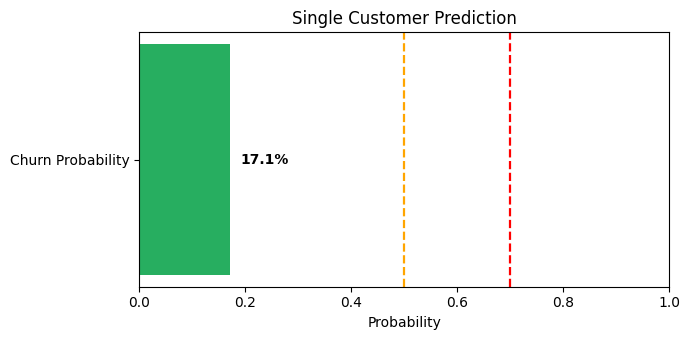


DRIFT MONITORING RUN - 2026-03-30 16:12:50
Batch ID: single_20260330_161248

[1/2] Running custom drift detector...

DRIFT DETECTION REPORT - ✗ CRITICAL
Timestamp: 2026-03-30T16:12:50.071533

Summary:
  Samples analyzed: 1
  Total features: 19
  Features drifted: 16
    - HIGH severity: 15
    - MEDIUM severity: 1

----------------------------------------------------------------------------------------------------
NUMERIC FEATURES (Z-Score + KS Test + PSI)
----------------------------------------------------------------------------------------------------
  Feature          Z-Score  KS Stat   KS p-val      PSI     Severity
----------------------------------------------------------------------------------------------------
  SeniorCitizen      0.439    0.670     0.6605   0.0439          LOW
* tenure             1.286    0.901     0.1984   0.1286       MEDIUM
  MonthlyCharges     0.664    0.747     0.5065   0.0664          LOW
  TotalCharges       0.563    0.713     0.5732   0.0563     

In [ ]:
# ========== USER INPUT: Interactive Customer Prediction ==========
print("=" * 75)
print("INTERACTIVE PREDICTION - Enter Your Customer Details")
print("=" * 75)
print("\n📝 Instructions: Modify the dictionary below with your customer's information")
print("   and run this cell to get a prediction.\n")

# Template for user to modify
user_customer = {
    'SeniorCitizen': 0,                                    # 0 or 1
    'tenure': 1,                                          # months (0-72)
    'PhoneService_Yes':0 ,                                 # 0 or 1
    'MultipleLines_Yes': 0,                                # 0 or 1
    'InternetService_Fiber optic': 1,                      # 1 if Fiber, 0 if DSL
    'InternetService_No': 1,                               # 1 if No internet
    'OnlineSecurity_Yes': 1,                               # 0 or 1
    'OnlineBackup_Yes': 1,                                 # 0 or 1
    'DeviceProtection_Yes': 1,                             # 0 or 1
    'TechSupport_Yes': 1,                                  # 0 or 1
    'StreamingTV_Yes': 1,                                  # 0 or 1
    'StreamingMovies_Yes': 1,                              # 0 or 1
    'Contract_One year': 0,                                # 1 if 1-year, 0 otherwise
    'Contract_Two year': 1,                                # 1 if 2-year, 0 otherwise
    'PaperlessBilling_Yes': 1,                             # 0 or 1
    'PaymentMethod_Credit card (automatic)': 1,            # 1 if Credit card
    'PaymentMethod_Electronic check': 1,                   # 1 if E-check
    'PaymentMethod_Mailed check': 1,                       # 1 if Mailed check
    'MonthlyCharges': 85.00,                               # $ amount
    'TotalCharges': 1020.00,                               # $ total lifetime
    'gender_Male': 1,                                      # 1 if Male, 0 if Female
    'Partner_Yes': 1,                                      # 0 or 1
    'Dependents_Yes': 0,                                   # 0 or 1
    'OnlineSecurity_No internet service': 0,               # 0 (not applicable if internet)
    'OnlineBackup_No internet service': 0,                 # 0 (not applicable if internet)
    'DeviceProtection_No internet service': 0,             # 0 (not applicable if internet)
    'TechSupport_No internet service': 0,                  # 0 (not applicable if internet)
    'StreamingTV_No internet service': 0,                  # 0 (not applicable if internet)
    'StreamingMovies_No internet service': 0               # 0 (not applicable if internet)
}

print("📊 CUSTOMER DETAILS (Modify values and rerun):")
print("-" * 75)
print(f"Tenure:                {user_customer['tenure']} months")
print(f"Monthly Charges:       ${user_customer['MonthlyCharges']}")
print(f"Total Charges:         ${user_customer['TotalCharges']}")
print(f"Senior Citizen:        {'Yes' if user_customer['SeniorCitizen'] == 1 else 'No'}")
print(f"Has Partner:           {'Yes' if user_customer['Partner_Yes'] == 1 else 'No'}")
print(f"Internet Service:      {'Fiber optic' if user_customer['InternetService_Fiber optic'] == 1 else ('DSL' if user_customer['InternetService_No'] == 0 else 'None')}")
print(f"Contract Type:         {'2-year' if user_customer['Contract_Two year'] == 1 else ('1-year' if user_customer['Contract_One year'] == 1 else 'Month-to-month')}")
print(f"Online Security:       {'Yes' if user_customer['OnlineSecurity_Yes'] == 1 else 'No'}")
print(f"Tech Support:          {'Yes' if user_customer['TechSupport_Yes'] == 1 else 'No'}")

# Get prediction
result_user = predict_single_customer(user_customer)

print(f"\n{'─' * 75}")
print(f"🔮 PREDICTION RESULTS:")
print(f"{'─' * 75}")
print(f"  Churn Prediction:      {result_user['prediction']}")
print(f"  Churn Probability:     {result_user['churn_probability']:.1%}")
print(f"  Risk Level:            {result_user['risk_level']}")
print(f"\n💡 RECOMMENDED ACTION:")
print(f"  {result_user['recommended_action']}")

# Provide guidance based on risk
if result_user['churn_probability'] > 0.7:
    print(f"\n⚠️  ACTION ITEMS:")
    print(f"  • Proactive outreach within 24-48 hours")
    print(f"  • Offer service bundle or contract incentive")
    print(f"  • Assign dedicated account manager")
    print(f"  • Escalate to retention specialist")
elif result_user['churn_probability'] > 0.5:
    print(f"\n📌 ACTION ITEMS:")
    print(f"  • Schedule courtesy check-in call")
    print(f"  • Prepare targeted retention offer")
    print(f"  • Monitor service quality metrics")
    print(f"  • Consider loyalty program enrollment")
else:
    print(f"\n✅ RECOMMENDED ACTIONS:")
    print(f"  • Continue standard customer care")
    print(f"  • Quarterly satisfaction surveys")
    print(f"  • Cross-sell opportunities")
    print(f"  • VIP loyalty program consideration")

# Save single prediction PNG artifact only
timestamp_single = datetime.now().strftime("%Y%m%d_%H%M%S")
single_prob = float(result_user["churn_probability"])
single_color = "#27ae60"
if single_prob > 0.7:
    single_color = "#e74c3c"
elif single_prob > 0.5:
    single_color = "#f39c12"

fig_single, ax_single = plt.subplots(figsize=(7, 3.5))
ax_single.barh(["Churn Probability"], [single_prob], color=single_color)
ax_single.axvline(0.5, color="orange", linestyle="--", linewidth=1.6)
ax_single.axvline(0.7, color="red", linestyle="--", linewidth=1.6)
ax_single.set_xlim(0, 1)
ax_single.set_title("Single Customer Prediction")
ax_single.set_xlabel("Probability")
ax_single.text(
    single_prob + 0.02 if single_prob < 0.88 else single_prob - 0.18,
    0,
    f"{single_prob:.1%}",
    va="center",
    fontweight="bold",
)

single_png_path = PREDICTION_DIR / f"single_prediction_{timestamp_single}.png"
fig_single.tight_layout()
fig_single.savefig(single_png_path, dpi=150, bbox_inches="tight")
plt.show()

# Run drift detection + alerting for this single prediction input
single_raw_df = build_raw_single_customer(user_customer)
single_drift_report = run_drift_and_alert(single_raw_df, batch_name=f"single_{timestamp_single}")

print("\n" + "=" * 75)
print("SINGLE PREDICTION PNG + DRIFT MONITORING")
print("=" * 75)
print(f"Single PNG:        {single_png_path}")
print(f"Drift status:      {single_drift_report['custom_detector']['overall_status']}")
print(f"Alert triggered:   {single_drift_report['alerting']['alert_triggered']}")
print(f"Alert level:       {single_drift_report['alerting']['alert_level']}")

C:\Users\ACER\AppData\Local\Temp\ipykernel_10824\1637909306.py:105: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_10824\1637909306.py:109: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.savefig(dashboard_png_path, dpi=160, bbox_inches='tight')
c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


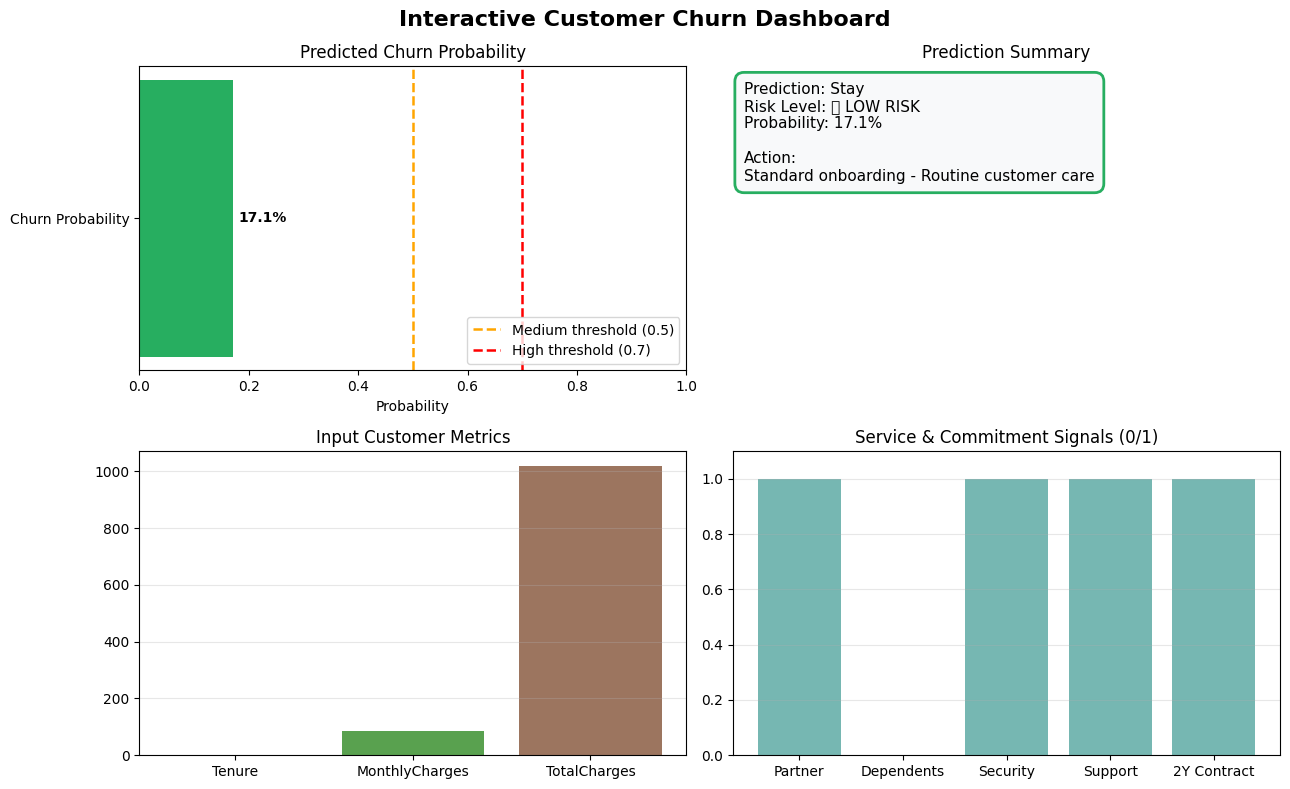


INTERACTIVE DASHBOARD REPORT SAVED
CSV report:      ..\data\predictions\interactive_prediction_20260330_161414.csv
Dashboard image: ..\data\predictions\interactive_dashboard_20260330_161414.png
HTML report:     ..\data\predictions\interactive_report_20260330_161414.html


In [16]:
# ========== DASHBOARD REPORT FOR INTERACTIVE PREDICTION ==========
from datetime import datetime
import matplotlib.pyplot as plt

# Ensure prediction output folder exists
prediction_dir = DATA_DIR / "predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)

# Build report dataset from interactive input + prediction result
timestamp_user = datetime.now().strftime("%Y%m%d_%H%M%S")
customer_id_user = user_customer.get('customerID', f'INTERACTIVE-{timestamp_user}')

contract_type_user = (
    "Two year" if user_customer.get('Contract_Two year', 0) == 1
    else "One year" if user_customer.get('Contract_One year', 0) == 1
    else "Month-to-month"
)

internet_service_user = (
    "Fiber optic" if user_customer.get('InternetService_Fiber optic', 0) == 1
    else "No" if user_customer.get('InternetService_No', 0) == 1
    else "DSL"
)

user_report_df = pd.DataFrame([{
    "customer_id": customer_id_user,
    "tenure_months": user_customer.get('tenure', np.nan),
    "monthly_charges": user_customer.get('MonthlyCharges', np.nan),
    "total_charges": user_customer.get('TotalCharges', np.nan),
    "internet_service": internet_service_user,
    "contract_type": contract_type_user,
    "prediction": result_user['prediction'],
    "churn_probability": float(result_user['churn_probability']),
    "risk_level": result_user['risk_level'],
    "recommended_action": result_user['recommended_action']
}])

# Save CSV report for this interactive run
interactive_csv_path = prediction_dir / f"interactive_prediction_{timestamp_user}.csv"
user_report_df.to_csv(interactive_csv_path, index=False)

# ---------- Build dashboard figure ----------
prob = float(result_user['churn_probability'])
risk_text = result_user['risk_level']
pred_text = result_user['prediction']

risk_color = '#27ae60'
if prob > 0.7:
    risk_color = '#e74c3c'
elif prob > 0.5:
    risk_color = '#f39c12'

fig, axs = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Interactive Customer Churn Dashboard', fontsize=16, fontweight='bold')

# 1) Probability bar with thresholds
axs[0, 0].barh(['Churn Probability'], [prob], color=risk_color)
axs[0, 0].axvline(0.5, color='orange', linestyle='--', linewidth=1.8, label='Medium threshold (0.5)')
axs[0, 0].axvline(0.7, color='red', linestyle='--', linewidth=1.8, label='High threshold (0.7)')
axs[0, 0].set_xlim(0, 1)
axs[0, 0].set_xlabel('Probability')
axs[0, 0].set_title('Predicted Churn Probability')
axs[0, 0].legend(loc='lower right')
axs[0, 0].text(prob + 0.01 if prob < 0.9 else prob - 0.15, 0, f'{prob:.1%}', va='center', fontweight='bold')

# 2) Prediction card
axs[0, 1].axis('off')
card_text = (
    f"Prediction: {pred_text}\n"
    f"Risk Level: {risk_text}\n"
    f"Probability: {prob:.1%}\n\n"
    f"Action:\n{result_user['recommended_action']}"
)
axs[0, 1].text(
    0.02, 0.95, card_text,
    va='top', ha='left', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor=risk_color, linewidth=2)
)
axs[0, 1].set_title('Prediction Summary')

# 3) Key customer metrics
metric_names = ['Tenure', 'MonthlyCharges', 'TotalCharges']
metric_vals = [
    user_customer.get('tenure', 0),
    user_customer.get('MonthlyCharges', 0),
    user_customer.get('TotalCharges', 0)
]
axs[1, 0].bar(metric_names, metric_vals, color=['#4e79a7', '#59a14f', '#9c755f'])
axs[1, 0].set_title('Input Customer Metrics')
axs[1, 0].grid(axis='y', alpha=0.3)

# 4) Service/commitment indicators
binary_features = {
    'Partner': user_customer.get('Partner_Yes', 0),
    'Dependents': user_customer.get('Dependents_Yes', 0),
    'Security': user_customer.get('OnlineSecurity_Yes', 0),
    'Support': user_customer.get('TechSupport_Yes', 0),
    '2Y Contract': user_customer.get('Contract_Two year', 0)
}
axs[1, 1].bar(binary_features.keys(), binary_features.values(), color='#76b7b2')
axs[1, 1].set_ylim(0, 1.1)
axs[1, 1].set_title('Service & Commitment Signals (0/1)')
axs[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save dashboard image
dashboard_png_path = prediction_dir / f"interactive_dashboard_{timestamp_user}.png"
fig.savefig(dashboard_png_path, dpi=160, bbox_inches='tight')
plt.show()

# ---------- Save HTML report ----------
html_report_path = prediction_dir / f"interactive_report_{timestamp_user}.html"

html_content = f"""
<!DOCTYPE html>
<html lang=\"en\">
<head>
  <meta charset=\"UTF-8\" />
  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1.0\" />
  <title>Interactive Churn Prediction Report</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 24px; background: #f7f8fa; color: #222; }}
    .card {{ background: #fff; border-radius: 10px; padding: 16px; margin-bottom: 14px; box-shadow: 0 2px 8px rgba(0,0,0,.06); }}
    .kpi {{ display: inline-block; margin-right: 20px; font-size: 18px; }}
    .risk {{ font-weight: 700; color: {risk_color}; }}
    table {{ border-collapse: collapse; width: 100%; }}
    th, td {{ text-align: left; padding: 8px; border-bottom: 1px solid #e7e7e7; }}
    th {{ background: #f1f3f5; }}
    .small {{ color: #666; font-size: 13px; }}
  </style>
</head>
<body>
  <h1>Interactive Customer Churn Prediction Report</h1>
  <div class=\"small\">Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</div>

  <div class=\"card\">
    <div class=\"kpi\"><b>Customer:</b> {customer_id_user}</div>
    <div class=\"kpi\"><b>Prediction:</b> {pred_text}</div>
    <div class=\"kpi\"><b>Probability:</b> {prob:.1%}</div>
    <div class=\"kpi risk\"><b>Risk:</b> {risk_text}</div>
  </div>

  <div class=\"card\">
    <h3>Recommended Action</h3>
    <p>{result_user['recommended_action']}</p>
  </div>

  <div class=\"card\">
    <h3>Customer Snapshot</h3>
    {user_report_df.to_html(index=False)}
  </div>

  <div class=\"card\">
    <h3>Dashboard Image</h3>
    <p class=\"small\">Saved separately as: {dashboard_png_path.name}</p>
    <img src=\"{dashboard_png_path.name}\" alt=\"Interactive dashboard\" style=\"max-width: 100%; border: 1px solid #ddd; border-radius: 8px;\" />
  </div>
</body>
</html>
"""

with open(html_report_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print("\n" + "=" * 75)
print("INTERACTIVE DASHBOARD REPORT SAVED")
print("=" * 75)
print(f"CSV report:      {interactive_csv_path}")
print(f"Dashboard image: {dashboard_png_path}")
print(f"HTML report:     {html_report_path}")

## 2c. Interactive Prediction Dashboard Report (Saved to predictions)

This section creates a visual dashboard and HTML report for the interactive customer prediction and saves both files to `../data/predictions/`.

## 3. Batch Prediction from CSV

Load customer data from a CSV file, process all customers at once, and generate predictions for downstream business use.

In [ ]:
def prepare_batch_data(df_raw, feature_names=feature_names):
    """
    Prepare raw customer data for batch prediction.
    
    Args:
        df_raw: DataFrame with raw customer data (before encoding)
        feature_names: Expected feature names from model training
    
    Returns:
        DataFrame ready for prediction
    """
    df = df_raw.copy()
    
    # Ensure numeric columns are properly typed
    numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # One-hot encode categorical columns (except customerID and target)
    exclude_cols = ['customerID', 'Churn']
    categorical_cols = df.select_dtypes(include='object').columns.tolist()
    categorical_cols = [col for col in categorical_cols if col not in exclude_cols]
    
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    # Reindex to match training features exactly
    df_encoded = df_encoded.reindex(columns=feature_names, fill_value=0)
    
    return df_encoded

# Load baseline test data
baseline_csv_path = DATA_DIR / "user_testing" / "baseline.csv"
print(f"Loading baseline customer data from: {baseline_csv_path}")
print()

if baseline_csv_path.exists():
    baseline_df = pd.read_csv(baseline_csv_path)
    print(f"✓ Loaded {len(baseline_df)} customers from baseline.csv")
    print(f"  Columns: {list(baseline_df.columns)}\n")
else:
    print(f"⚠ File not found. Creating sample data for demonstration...\n")
    # Create minimal sample data for demonstration
    baseline_df = pd.DataFrame({
        'customerID': ['DEMO-001', 'DEMO-002', 'DEMO-003'],
        'gender': ['Male', 'Female', 'Male'],
        'SeniorCitizen': [0, 1, 0],
        'Partner': ['Yes', 'No', 'Yes'],
        'Dependents': ['No', 'No', 'Yes'],
        'tenure': [12, 45, 2],
        'PhoneService': ['Yes', 'Yes', 'Yes'],
        'MultipleLines': ['No', 'Yes', 'No'],
        'InternetService': ['DSL', 'Fiber optic', 'Fiber optic'],
        'OnlineSecurity': ['Yes', 'No', 'No'],
        'OnlineBackup': ['No', 'Yes', 'No'],
        'DeviceProtection': ['Yes', 'No', 'No'],
        'TechSupport': ['No', 'No', 'Yes'],
        'StreamingTV': ['Yes', 'Yes', 'No'],
        'StreamingMovies': ['No', 'Yes', 'No'],
        'Contract': ['Month-to-month', 'Two year', 'Month-to-month'],
        'PaperlessBilling': ['Yes', 'No', 'Yes'],
        'PaymentMethod': ['Electronic check', 'Bank transfer (automatic)', 'Mailed check'],
        'MonthlyCharges': [50.5, 85.25, 45.2],
        'TotalCharges': [606.0, 3836.25, 90.4]
    })

# Prepare data for batch prediction
print("Preparing data for batch prediction...")
batch_data_encoded = prepare_batch_data(baseline_df)

print(f"✓ Data prepared with {batch_data_encoded.shape[0]} customers and {batch_data_encoded.shape[1]} features")
print(f"  Expected features: {len(feature_names)}")
print(f"  Features match: {batch_data_encoded.shape[1] == len(feature_names)}\n")

# ========== BATCH PREDICTIONS ==========
print("=" * 75)
print("BATCH PREDICTION RESULTS")
print("=" * 75 + "\n")

# Make predictions
predictions = xgb_model.predict(batch_data_encoded)
probabilities = xgb_model.predict_proba(batch_data_encoded)[:, 1]

# Classify risk levels
risk_levels = []
for prob in probabilities:
    if prob > 0.7:
        risk_levels.append('HIGH')
    elif prob > 0.5:
        risk_levels.append('MEDIUM')
    else:
        risk_levels.append('LOW')

# Create results dataframe
results_df = pd.DataFrame({
    'customerID': baseline_df['customerID'],
    'tenure': baseline_df['tenure'],
    'monthly_charges': baseline_df['MonthlyCharges'],
    'contract_type': baseline_df['Contract'],
    'churn_prediction': ['Churn' if p == 1 else 'Stay' for p in predictions],
    'churn_probability': probabilities,
    'risk_level': risk_levels
})

# Display results
print("Individual Predictions:")
print(results_df.to_string(index=False))

print("\n" + "=" * 75)
print("BATCH SUMMARY STATISTICS")
print("=" * 75)
print(f"Total Customers:              {len(results_df)}")
print(f"Predicted to Churn:           {(results_df['churn_prediction'] == 'Churn').sum()} ({(results_df['churn_prediction'] == 'Churn').sum() / len(results_df) * 100:.1f}%)")
print(f"Predicted to Stay:            {(results_df['churn_prediction'] == 'Stay').sum()} ({(results_df['churn_prediction'] == 'Stay').sum() / len(results_df) * 100:.1f}%)")
print(f"\nRisk Breakdown:")
print(f"  🔴 HIGH Risk (>70%):        {(results_df['risk_level'] == 'HIGH').sum()} customers")
print(f"  🟡 MEDIUM Risk (50-70%):    {(results_df['risk_level'] == 'MEDIUM').sum()} customers")
print(f"  🟢 LOW Risk (<50%):         {(results_df['risk_level'] == 'LOW').sum()} customers")
print(f"\nChurn Probability Statistics:")
print(f"  Mean:                       {probabilities.mean():.1%}")
print(f"  Median:                     {np.median(probabilities):.1%}")
print(f"  Min:                        {probabilities.min():.1%}")
print(f"  Max:                        {probabilities.max():.1%}")

# Save batch prediction PNG artifact only
timestamp_batch = datetime.now().strftime("%Y%m%d_%H%M%S")
batch_png_path = PREDICTION_DIR / f"batch_prediction_{timestamp_batch}.png"

fig_batch, ax_batch = plt.subplots(figsize=(8, 4))
risk_counts = results_df['risk_level'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'], fill_value=0)
ax_batch.bar(risk_counts.index, risk_counts.values, color=['#27ae60', '#f39c12', '#e74c3c'])
ax_batch.set_title('Batch Risk Level Distribution')
ax_batch.set_ylabel('Customer Count')
ax_batch.grid(axis='y', alpha=0.25)
for i, v in enumerate(risk_counts.values):
    ax_batch.text(i, v + 0.02, str(int(v)), ha='center', fontweight='bold')
fig_batch.tight_layout()
fig_batch.savefig(batch_png_path, dpi=150, bbox_inches='tight')
plt.show()

# Run drift detection + alerting for this batch input
batch_drift_report = run_drift_and_alert(
    baseline_df.copy(),
    batch_name=f"batch_{timestamp_batch}",
)

print("\n" + "=" * 75)
print("BATCH PREDICTION PNG + DRIFT MONITORING")
print("=" * 75)
print(f"Batch PNG:         {batch_png_path}")
print(f"Drift status:      {batch_drift_report['custom_detector']['overall_status']}")
print(f"Alert triggered:   {batch_drift_report['alerting']['alert_triggered']}")
print(f"Alert level:       {batch_drift_report['alerting']['alert_level']}")

Loading baseline customer data from: ..\data\user_testing\baseline.csv

✓ Loaded 10 customers from baseline.csv
  Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Preparing data for batch prediction...
✓ Data prepared with 10 customers and 30 features
  Expected features: 30
  Features match: True

BATCH PREDICTION RESULTS

Individual Predictions:
customerID  tenure  monthly_charges  contract_type churn_prediction  churn_probability risk_level
  TEST-001      12            50.50 Month-to-month            Churn           0.539404     MEDIUM
  TEST-002      45            85.25       One year             Stay           0.470807        LOW
  TEST-003       2            45.20 Month-to-month            Churn    

## 4. Prediction Results Visualization

Create visualizations to understand the distribution of churn predictions across the customer batch.

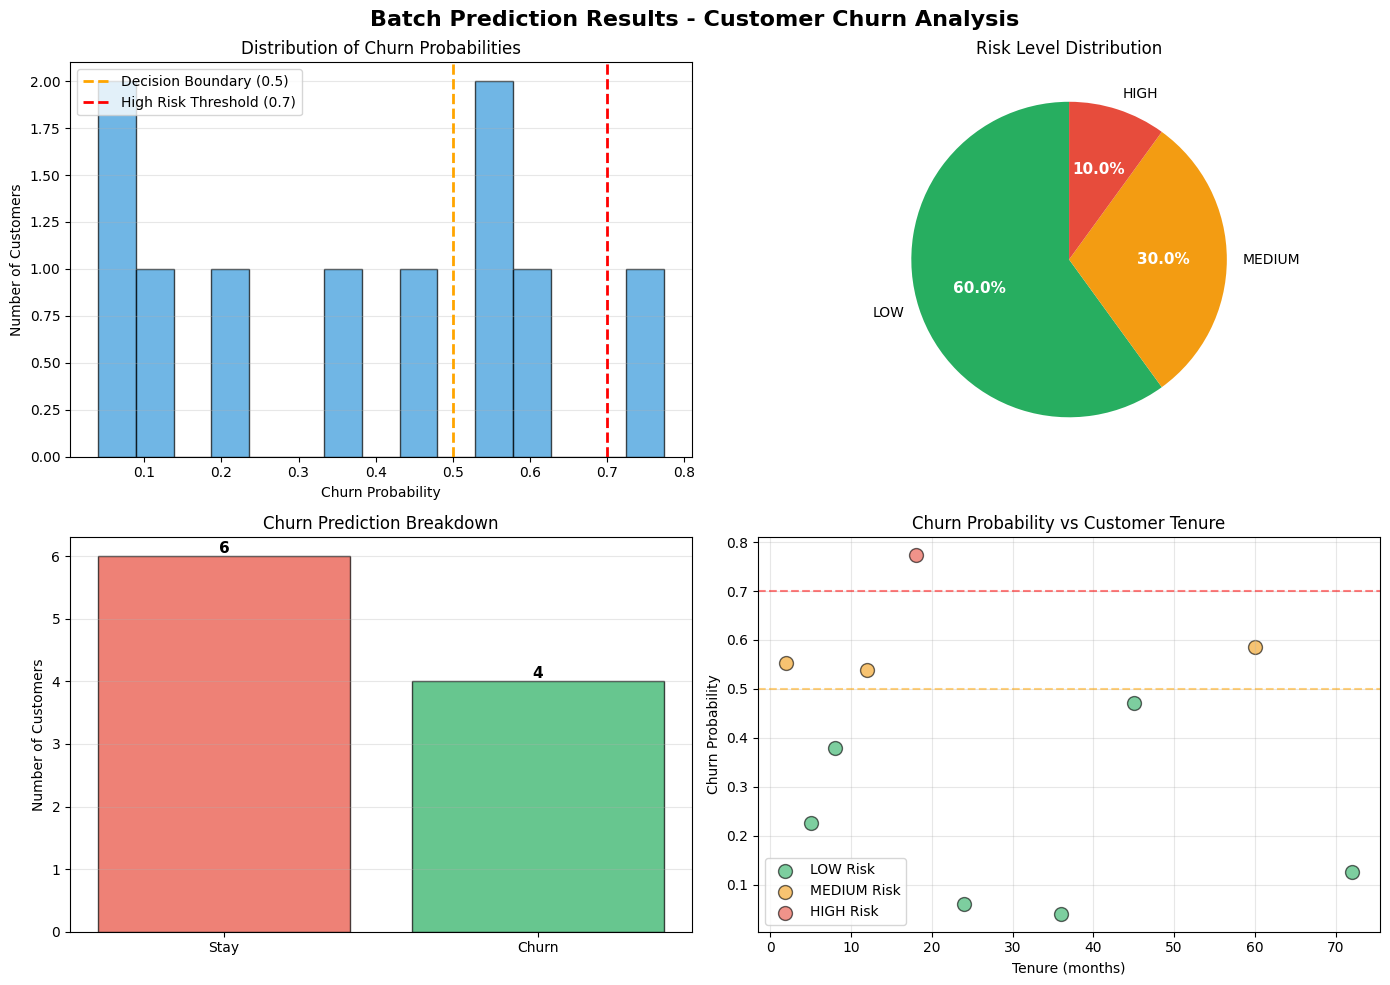

✓ Visualization complete


In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Batch Prediction Results - Customer Churn Analysis', fontsize=16, fontweight='bold')

# 1. Histogram of Churn Probabilities
ax1 = axes[0, 0]
ax1.hist(probabilities, bins=15, color='#3498db', edgecolor='black', alpha=0.7)
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
ax1.axvline(0.7, color='red', linestyle='--', linewidth=2, label='High Risk Threshold (0.7)')
ax1.set_xlabel('Churn Probability')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Distribution of Churn Probabilities')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Risk Level Breakdown (Pie Chart)
ax2 = axes[0, 1]
risk_counts = results_df['risk_level'].value_counts()
colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#27ae60'}
pie_colors = [colors.get(risk, '#95a5a6') for risk in risk_counts.index]
wedges, texts, autotexts = ax2.pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax2.set_title('Risk Level Distribution')

# 3. Prediction Breakdown (Bar Chart)
ax3 = axes[1, 0]
churn_counts = results_df['churn_prediction'].value_counts()
bars = ax3.bar(churn_counts.index, churn_counts.values, color=['#e74c3c', '#27ae60'], edgecolor='black', alpha=0.7)
ax3.set_ylabel('Number of Customers')
ax3.set_title('Churn Prediction Breakdown')
ax3.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Churn Probability vs Tenure
ax4 = axes[1, 1]
colors_map = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#27ae60'}
for risk in ['LOW', 'MEDIUM', 'HIGH']:
    mask = results_df['risk_level'] == risk
    ax4.scatter(results_df[mask]['tenure'], results_df[mask]['churn_probability'], 
               s=100, alpha=0.6, color=colors_map[risk], label=f'{risk} Risk', edgecolors='black', linewidth=1)

ax4.axhline(0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.5)
ax4.axhline(0.7, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
ax4.set_xlabel('Tenure (months)')
ax4.set_ylabel('Churn Probability')
ax4.set_title('Churn Probability vs Customer Tenure')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")


## 5. Export Predictions to CSV

Save prediction results to a CSV file for downstream business systems and analysis.

In [8]:
from datetime import datetime

# Create comprehensive predictions export with all relevant information
export_df = results_df.copy()

# Add additional details from original data
export_df['internet_service'] = baseline_df['InternetService'].values
export_df['contract'] = baseline_df['Contract'].values
export_df['total_charges'] = baseline_df['TotalCharges'].values

# Round probability to 4 decimal places for export
export_df['churn_probability'] = export_df['churn_probability'].round(4)

# Reorder columns for clarity
export_columns = [
    'customerID', 
    'tenure', 
    'monthly_charges',
    'total_charges',
    'internet_service',
    'contract',
    'churn_prediction',
    'churn_probability',
    'risk_level'
]
export_df = export_df[export_columns]

# Create output directory if it doesn't exist
output_dir = DATA_DIR / "predictions"
output_dir.mkdir(parents=True, exist_ok=True)

# Generate timestamped filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = output_dir / f"churn_predictions_{timestamp}.csv"

# Export to CSV
export_df.to_csv(output_path, index=False)

print("=" * 75)
print("PREDICTION EXPORT")
print("=" * 75 + "\n")
print(f"✓ Predictions exported to: {output_path}\n")

print("Export File Preview (first 10 rows):")
print(export_df.head(10).to_string(index=False))

print(f"\n{'-' * 75}")
print("Export Summary:")
print(f"{'-' * 75}")
print(f"Total records exported:     {len(export_df)}")
print(f"Columns included:           {len(export_columns)}")
print(f"File size:                  {output_path.stat().st_size / 1024:.2f} KB")
print(f"Timestamp:                  {timestamp}")

# Create a summary report
summary_path = output_dir / f"churn_predictions_summary_{timestamp}.txt"
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("=" * 75 + "\n")
    f.write("CHURN PREDICTION BATCH REPORT\n")
    f.write("=" * 75 + "\n\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("SUMMARY STATISTICS\n")
    f.write(f"{'-' * 75}\n")
    f.write(f"Total Customers:              {len(export_df)}\n")
    f.write(f"Predicted to Churn:           {(export_df['churn_prediction'] == 'Churn').sum()}\n")
    f.write(f"Predicted to Stay:            {(export_df['churn_prediction'] == 'Stay').sum()}\n\n")
    
    f.write("RISK BREAKDOWN\n")
    f.write(f"{'-' * 75}\n")
    f.write(f"HIGH Risk (>70%):             {(export_df['risk_level'] == 'HIGH').sum()}\n")
    f.write(f"MEDIUM Risk (50-70%):         {(export_df['risk_level'] == 'MEDIUM').sum()}\n")
    f.write(f"LOW Risk (<50%):              {(export_df['risk_level'] == 'LOW').sum()}\n\n")
    
    f.write("PROBABILITY DISTRIBUTION\n")
    f.write(f"{'-' * 75}\n")
    f.write(f"Mean:                         {export_df['churn_probability'].mean():.4f}\n")
    f.write(f"Median:                       {export_df['churn_probability'].median():.4f}\n")
    f.write(f"Min:                          {export_df['churn_probability'].min():.4f}\n")
    f.write(f"Max:                          {export_df['churn_probability'].max():.4f}\n")
    f.write(f"Std Dev:                      {export_df['churn_probability'].std():.4f}\n\n")
    
    f.write("HIGH RISK CUSTOMERS (ACTION REQUIRED)\n")
    f.write(f"{'-' * 75}\n")
    high_risk = export_df[export_df['risk_level'] == 'HIGH'].sort_values('churn_probability', ascending=False)
    if len(high_risk) > 0:
        for idx, row in high_risk.iterrows():
            f.write(f"  {row['customerID']}: {row['churn_probability']:.1%} churn probability\n")
    else:
        f.write("  No high-risk customers\n")

print(f"\n✓ Summary report saved to: {summary_path}")

PREDICTION EXPORT

✓ Predictions exported to: ..\data\predictions\churn_predictions_20260330_160102.csv

Export File Preview (first 10 rows):
customerID  tenure  monthly_charges  total_charges internet_service       contract churn_prediction  churn_probability risk_level
  TEST-001      12            50.50         606.00              DSL Month-to-month            Churn             0.5394     MEDIUM
  TEST-002      45            85.25        3836.25      Fiber optic       One year             Stay             0.4708        LOW
  TEST-003       2            45.20          90.40              DSL Month-to-month            Churn             0.5526     MEDIUM
  TEST-004      24            25.75         619.00              DSL       Two year             Stay             0.0614        LOW
  TEST-005      60            95.00        5700.00      Fiber optic Month-to-month            Churn             0.5849     MEDIUM
  TEST-006       8            79.85         638.80      Fiber optic       One 